In [ ]:
# ==========================================
# Smart Email Classifier + Urgency Detection
# Dataset: final_enron_dataset.csv
# ==========================================

import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from torch.optim import AdamW

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ==========================================
# 1 Load Dataset
# ==========================================

df = pd.read_csv("/content/drive/MyDrive/final_enron_dataset.csv")

print("Dataset shape:", df.shape)

df = df[['cleaned_text','category','urgency']]

df.dropna(inplace=True)

print(df['cleaned_text'].head())
print(df['category'].value_counts())

Dataset shape: (4777, 5)
0    traveling business meeting take fun trip espec...
1                               test successful way go
2    randy send schedule salary level everyone sche...
3            greg either next tuesday thursday phillip
4    please cc following distribution list update p...
Name: cleaned_text, dtype: object
category
request      1862
spam         1833
feedback      835
complaint     247
Name: count, dtype: int64


Example mapping:
Complaint → 0
Feedback → 1
Request → 2
Spam → 3


In [ ]:
# ==========================================
# 2 Encode Labels
# ==========================================

from sklearn.preprocessing import LabelEncoder

# Normalize category labels
df['category'] = df['category'].str.lower().str.strip()

# Normalize urgency labels
df['urgency'] = df['urgency'].str.lower().str.strip()

# Initialize encoders
category_encoder = LabelEncoder()
urgency_encoder = LabelEncoder()

# Encode labels
df['category_label'] = category_encoder.fit_transform(df['category'])
df['urgency_label'] = urgency_encoder.fit_transform(df['urgency'])

# Print label mappings
print("Categories:", list(category_encoder.classes_))
print("Urgency Levels:", list(urgency_encoder.classes_))

print(df[['category','category_label']].drop_duplicates())
print(df[['urgency','urgency_label']].drop_duplicates())

Categories: ['complaint', 'feedback', 'request', 'spam']
Urgency Levels: ['high', 'low', 'medium']
     category  category_label
0     request               2
1        spam               3
4    feedback               1
14  complaint               0
  urgency  urgency_label
0     low              1
4  medium              2
9    high              0


In [ ]:
# ==========================================
# 3 Balance Dataset
# ==========================================

print("Before balancing:")
print(df['category'].value_counts())

complaint_df = df[df['category'] == 'complaint']

complaint_upsampled = complaint_df.sample(
    n=800,
    replace=True,
    random_state=42
)

df_balanced = pd.concat([
    df[df['category'] == 'request'],
    df[df['category'] == 'spam'],
    df[df['category'] == 'feedback'],
    complaint_upsampled
])

df_balanced = df_balanced.sample(frac=1).reset_index(drop=True)

print("After balancing:")
print(df_balanced['category'].value_counts())

Before balancing:
category
request      1862
spam         1833
feedback      835
complaint     247
Name: count, dtype: int64
After balancing:
category
request      1862
spam         1833
feedback      835
complaint     800
Name: count, dtype: int64


### Train-Test Split

The dataset is divided into two parts:

Training Data – used to train the DistilBERT model.
Testing Data – used to evaluate the model performance.

Typically, 80% of the data is used for training and 20% for testing.
This ensures the model is evaluated on unseen data.

In [ ]:
# ==========================================
# 4 Train Test Split
# ==========================================

X = df_balanced['cleaned_text']
y = df_balanced['category_label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:

# ==========================================
# 5 Tokenizer
# ==========================================

tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

MAX_LEN = 128
BATCH_SIZE = 32
EPOCHS = 4


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
# ==========================================
# 6 Dataset Class
# ==========================================

class EmailDataset(Dataset):

    def __init__(self, texts, labels):
        self.texts = texts.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):

        text = str(self.texts[idx])
        label = int(self.labels[idx])

        encoding = tokenizer(
            text,
            max_length=MAX_LEN,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long)
        }

In [ ]:
# ==========================================
# 7 DataLoaders
# ==========================================

train_dataset = EmailDataset(X_train, y_train)
val_dataset = EmailDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    num_workers=2
)

In [ ]:
# ==========================================
# 8 Model initialization
# ==========================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(category_encoder.classes_)
)

model.to(device)

optimizer = AdamW(model.parameters(), lr=2e-5)

# Handle class imbalance
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = torch.nn.CrossEntropyLoss(weight=class_weights)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
batch = next(iter(train_loader))

print(batch["input_ids"].shape)
print(batch["attention_mask"].shape)
print(batch["labels"].shape)

torch.Size([32, 128])
torch.Size([32, 128])
torch.Size([32])


In [ ]:
# ==========================================
# 8 Training + Save Best Model
# ==========================================

print("Training model...")
best_accuracy = 0

MODEL_PATH = "email_classifier_model"

for epoch in range(EPOCHS):

    model.train()
    total_loss = 0

    for batch in train_loader:

        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits

        loss = criterion(logits, labels)

        total_loss += loss.item()

        loss.backward()
        optimizer.step()

    avg_loss = total_loss / len(train_loader)

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("Training Loss:", avg_loss)

    # -------- Validation --------

    model.eval()

    predictions = []
    true_labels = []

    with torch.no_grad():

        for batch in val_loader:

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()

            predictions.extend(preds)
            true_labels.extend(batch["labels"].cpu().numpy())

    accuracy = accuracy_score(true_labels, predictions)

    print("Validation Accuracy:", accuracy)

    # -------- Save Best Model --------

    if accuracy > best_accuracy:

        best_accuracy = accuracy

        model.save_pretrained(MODEL_PATH)
        tokenizer.save_pretrained(MODEL_PATH)

        print("Best model saved!")

Training model...

Epoch 1/4
Training Loss: 1.0723892521502367
Validation Accuracy: 0.8161350844277674


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best model saved!

Epoch 2/4
Training Loss: 0.32464397537396916
Validation Accuracy: 0.9108818011257036


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best model saved!

Epoch 3/4
Training Loss: 0.1271325878854563
Validation Accuracy: 0.9465290806754222


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best model saved!

Epoch 4/4
Training Loss: 0.06756901412979881
Validation Accuracy: 0.9549718574108818


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best model saved!


### Save Trained Model

After training, the trained model is saved to disk so it can be reused without retraining.

The following components are saved:
- DistilBERT model weights
- tokenizer
- category encoder
- urgency encoder

This enables the model to be loaded later for predictions.

In [ ]:
# ==========================================
# 9 Save Model
# ==========================================

import os
import pickle

MODEL_PATH = "email_classifier_model"

os.makedirs(MODEL_PATH, exist_ok=True)

# Save DistilBERT model
model.save_pretrained(MODEL_PATH)

# Save tokenizer
tokenizer.save_pretrained(MODEL_PATH)

# Save category encoder
with open(f"{MODEL_PATH}/category_encoder.pkl", "wb") as f:
    pickle.dump(category_encoder, f)

# Save urgency encoder
with open(f"{MODEL_PATH}/urgency_encoder.pkl", "wb") as f:
    pickle.dump(urgency_encoder, f)

print("Model and encoders saved successfully.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and encoders saved successfully.


In [ ]:


# ==========================================
# 10 Evaluation
# ==========================================

model.eval()

predictions = []
true_labels = []

with torch.no_grad():

    for batch in val_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()

        predictions.extend(preds)
        true_labels.extend(batch["labels"].cpu().numpy())

accuracy = accuracy_score(true_labels, predictions)

precision, recall, f1, _ = precision_recall_fscore_support(
    true_labels,
    predictions,
    average="weighted"
)

print("\nModel Performance")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)



Model Performance
Accuracy: 0.9549718574108818
Precision: 0.9564702062985636
Recall: 0.9549718574108818
F1 Score: 0.9551752966728031


### Confusion Matrix Visualization

The confusion matrix provides a detailed view of model predictions.

Rows represent actual categories and columns represent predicted categories.

Correct predictions appear along the diagonal of the matrix, while off-diagonal values represent misclassifications.

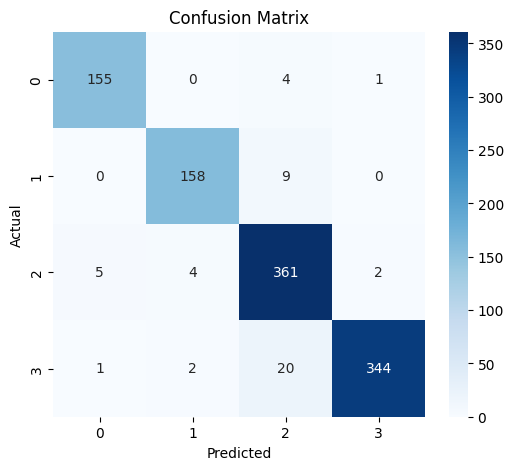

In [ ]:

# ==========================================
# 11 Confusion Matrix
# ==========================================

cm = confusion_matrix(true_labels, predictions)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Rule-Based Urgency Detection

To improve urgency prediction, a rule-based system is used.

The system checks for urgent keywords such as:
urgent, asap, immediately, deadline, priority.

If these keywords are present in the email text, the urgency level is automatically set to HIGH.

In [ ]:
# ==========================================
# 12 Rule Based Urgency Detection
# ==========================================

urgent_keywords = [
    "urgent",
    "asap",
    "immediately",
    "deadline",
    "priority",
    "today",
    "right away"
]

def rule_based_urgency(text):

    text = text.lower()

    for word in urgent_keywords:
        if word in text:
            return "high"

    return "low"

In [ ]:
# ==========================================
# 13 Hybrid Urgency Logic
# ==========================================

def final_urgency_prediction(text, ml_prediction):

    rule_pred = rule_based_urgency(text)

    # Rule-based override
    if rule_pred == "high":
        return "high"

    # Convert ML label → text
    return urgency_encoder.inverse_transform([ml_prediction])[0]

In [ ]:
# ==========================================
# 14 Prediction Pipeline
# ==========================================

def predict_email(email_text):

    encoding = tokenizer(
        email_text,
        max_length=MAX_LEN,
        padding="max_length",
        truncation=True,
        return_tensors="pt"
    )

    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)

    model.eval()

    with torch.no_grad():

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        probs = torch.softmax(outputs.logits, dim=1)

        confidence, pred = torch.max(probs, dim=1)

    # Category prediction
    category = category_encoder.inverse_transform([pred.item()])[0]

    # ML urgency prediction (example placeholder)
    ml_urgency_pred = 0   # replace if urgency ML model exists

    # Hybrid urgency detection
    urgency = final_urgency_prediction(email_text, ml_urgency_pred)

    return category, urgency, confidence.item()

In [ ]:
# ==========================================
# 15 Store Results
# ==========================================

import os

def store_result(email, category, urgency, confidence):

    data = {
        "Email_Text": email,
        "Predicted_Category": category,
        "Urgency_Level": urgency,
        "Confidence": confidence,
        "Timestamp": datetime.now()
    }

    result_df = pd.DataFrame([data])

    file_exists = os.path.isfile("classified_emails.csv")

    result_df.to_csv(
        "classified_emails.csv",
        mode="a",
        index=False,
        header=not file_exists
    )

In [ ]:

# ==========================================
# 16 Test Example
# ==========================================

email ="Could you please send me the latest sales report for the last quarter? I need it for tomorrow's meeting with the management team."
category, urgency, confidence = predict_email(email)

print("\nPrediction Result")
print("Category:", category)
print("Urgency:", urgency)
print("Confidence:", confidence)

store_result(email, category, urgency, confidence)


Prediction Result
Category: spam
Urgency: high
Confidence: 0.8060715794563293
